# IPL Match Analysis & EDA — Introduction
This project focuses on Exploratory Data Analysis (EDA) of IPL 2022 match data to understand team performance, toss decisions, match results, player performances, and venue-wise trends.
The dataset contains information about 74 IPL matches, including teams, venues, toss results, first- and second-innings scores, match winners, winning margins, Player of the Match, top scorers, and bowling performances.
Using Python, Pandas, Matplotlib, and Seaborn, the project cleans and analyzes the data and presents the findings through visualizations.
Main objectives
- Analyze team-wise match wins
- Study the relationship between toss winner and match winner
- Analyze toss decisions
- Identify top-performing players
- Analyze winning margins and methods
- Explore venue-wise match and team performance
- Extract meaningful insights from the IPL 2022 dataset
The goal is to convert raw IPL match data into clear, understandable insights through data analysis and visualization.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("IPL.csv")

# Basic imformation 

In [11]:
print(f"The total rows in the daset is {df.shape[0]} and total columns are {df.shape[1]} .")

The total rows in the daset is 74 and total columns are 20 .


In [5]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [15]:
df.tail()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22
73,74,"May 29,2022","Narendra Modi Stadium, Ahmedabad",Gujarat,Rajasthan,Final,Rajasthan,Bat,130,9,133,3,Gujarat,Wickets,7,Hardik Pandya,Shubman Gill,45,Hardik Pandya,3--17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [13]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


In [7]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

# Most matches win by the team 

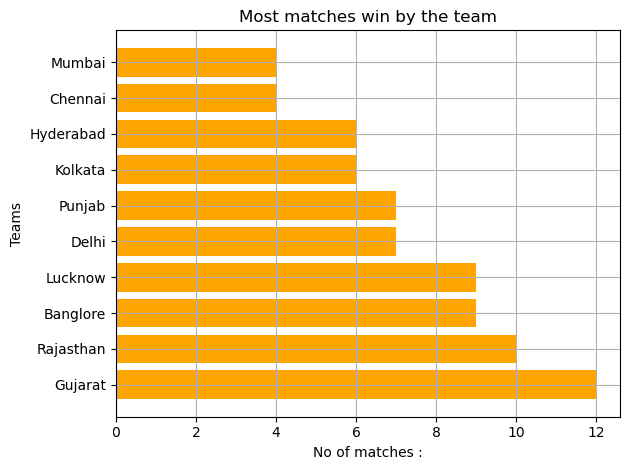

In [124]:
Match_winner=df["match_winner"].value_counts()
plt.barh(Match_winner.index,Match_winner.values,color="orange")
plt.title("Most matches win by the team")
plt.xlabel("No of matches :")
plt.ylabel("Teams")
plt.grid()
plt.tight_layout()
plt.show() 

# Toss decision trends

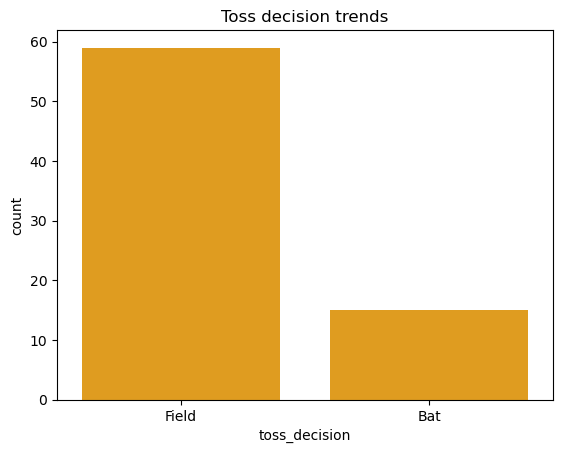

In [54]:
sns.countplot(x=df["toss_decision"],color="orange")
plt.title("Toss decision trends")
plt.show()

# Toss Winner vs Match Winner

In [77]:
df["toss_match_win"] = df["toss_winner"] == df["match_winner"]
df["toss_match_win"].value_counts()

toss_match_win
False    38
True     36
Name: count, dtype: int64

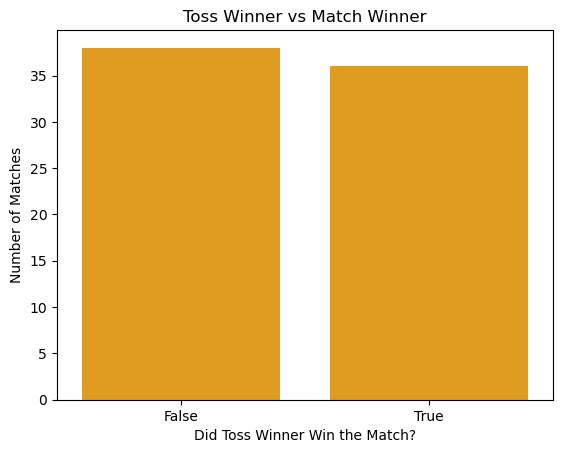

In [81]:
sns.countplot(x="toss_match_win",color="orange", data=df)

plt.title("Toss Winner vs Match Winner")
plt.xlabel("Did Toss Winner Win the Match?")
plt.ylabel("Number of Matches")

plt.show()

# How do teams win? (Runs vs Wickets)

In [93]:
df["won_by"].value_counts()

won_by
Wickets    37
Runs       37
Name: count, dtype: int64

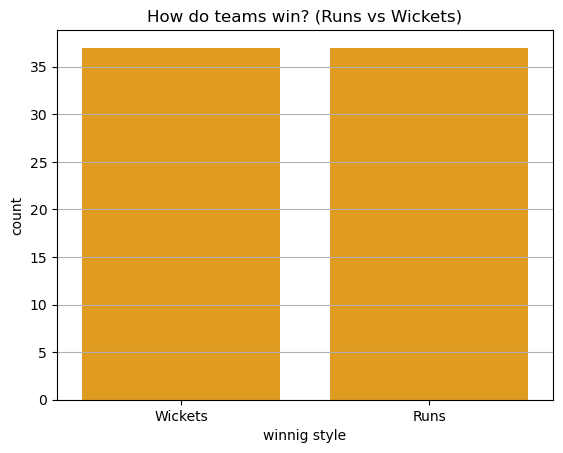

In [95]:

sns.countplot(x=df["won_by"],color="orange")
plt.grid(axis="y")
plt.title("How do teams win? (Runs vs Wickets)")
plt.xlabel("winnig style")
plt.show()

# Most "Player of the Match" Awards


In [104]:
Most_POM=df["player_of_the_match"].value_counts().head(5)
Most_POM

player_of_the_match
Kuldeep Yadav      4
Jos Buttler        3
Umesh Yadav        2
Quinton de Kock    2
David Miller       2
Name: count, dtype: int64

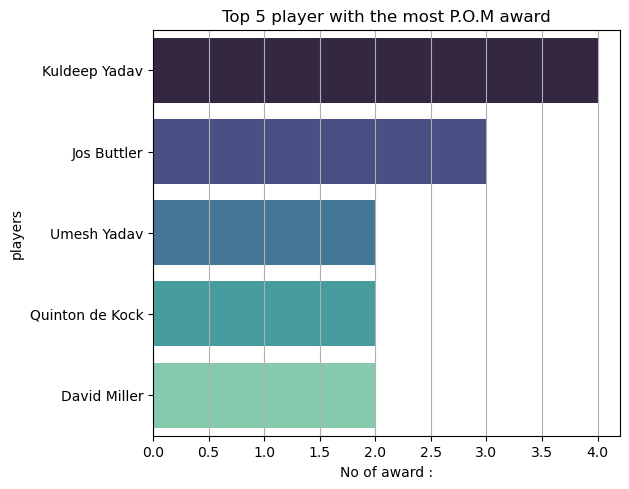

In [122]:
sns.barplot(x = Most_POM.values , y = Most_POM.index,palette='mako')
plt.title("Top 10 plauers with man of the match")
plt.grid(axis="x")
plt.tight_layout()
plt.title("Top 5 player with the most P.O.M award")
plt.xlabel("No of award :")
plt.ylabel("players")
plt.show()

# Top 5 batting figures 

In [137]:
Batters=df.groupby("top_scorer")["highscore"].sum().sort_values(ascending=False).head(5)
Batters

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Shubman Gill       288
Faf du Plessis     257
Name: highscore, dtype: int64

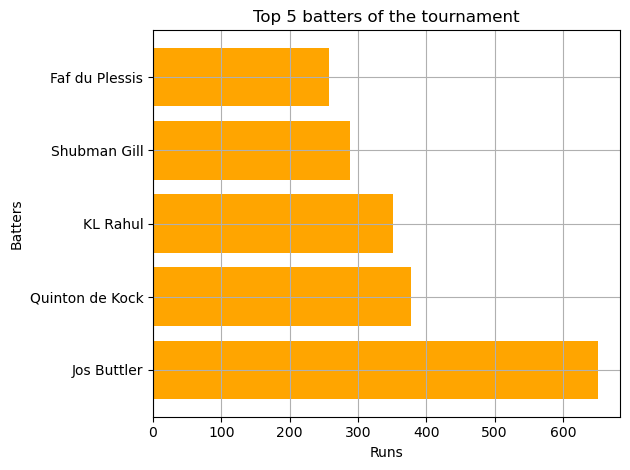

In [158]:
plt.barh(Batters.index,Batters.values,color="orange")
plt.title("Top 5 batters of the tournament")
plt.xlabel("Runs")
plt.ylabel("Batters")
plt.grid()
plt.tight_layout()
plt.show()

# Top 5 Bolling figures

#1.Extract the feature and create the new column names as highest_wickets
#2.change the new column daattype from STRING to  INT
#3.Make the graph

In [154]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head()


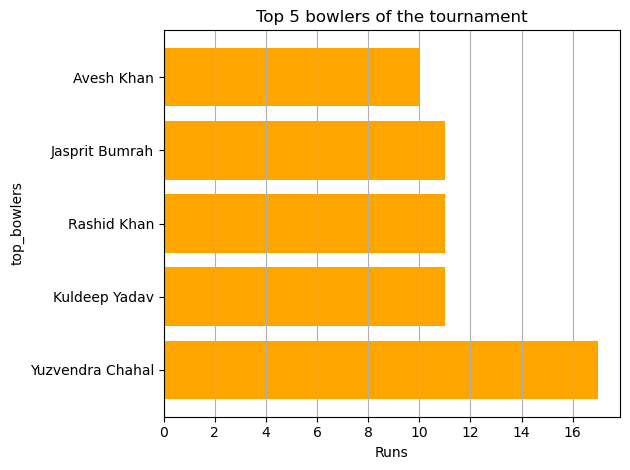

In [157]:
plt.barh(top_bowlers.index,top_bowlers.values,color="orange")
plt.title("Top 5 bowlers of the tournament")
plt.xlabel("Runs")
plt.ylabel("top_bowlers")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

# Most matches played on the venue

In [165]:
venue=df["venue"].value_counts()

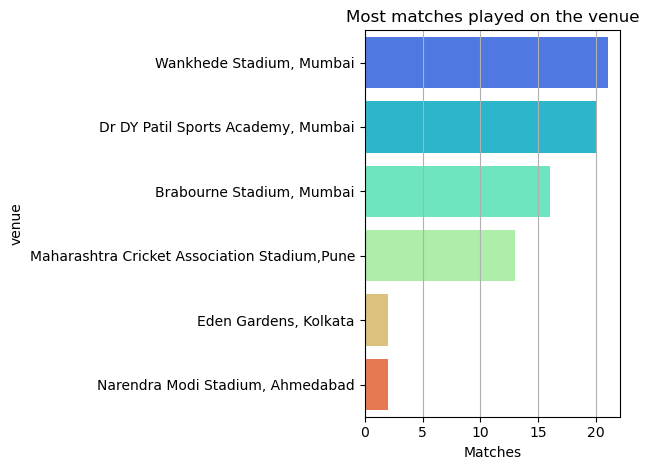

In [174]:
sns.barplot(y=venue.index,x=venue.values,palette="rainbow")
plt.title("Most matches played on the venue")
plt.xlabel("Matches")
plt.ylabel("venue")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

# Key Insights

1. **Team Performance**
   - Some teams recorded considerably more wins than others during the 2022 IPL season.
   - This shows differences in overall team performance across the tournament.

2. **Toss Decision**
   - Teams showed a clear preference for one of the available toss decisions.
   - This indicates that the choice made after winning the toss was not evenly distributed.

3. **Toss Winner vs Match Winner**
   - Winning the toss did not always result in winning the match.
   - Therefore, the toss alone cannot be considered a direct indicator of match success.

4. **Winning Method**
   - Teams won matches through both runs and wickets.
   - Comparing these two methods shows how frequently teams successfully defended totals versus chased targets.

5. **Player of the Match**
   - A small number of players received multiple Player of the Match awards.
   - These players had a significant individual impact across the tournament.

6. **Batting Performance**
   - The top-scoring players contributed substantially to their teams' batting performance.
   - High individual scores were an important part of successful batting performances.

7. **Bowling Performance**
   - The analysis identifies the bowlers with the highest recorded wicket figures in the dataset.
   - This helps compare individual bowling contributions.

8. **Venue Analysis**
   - The number of matches was not equally distributed across venues.
   - Some venues hosted substantially more matches than others.

9. **Venue and Team Performance**
   - The dataset can be used to compare which teams won the most matches at individual venues.
   - This provides a venue-specific view of team performance.